# W03B · 블록과 생성 관찰실
2026-09-16 수요일 · W03A를 완료하지 않아도 시작합니다.
[강의노트](https://github.com/lunalab-ai/genAI/blob/main/course/notion/w03b/w03b-transformer-walkthrough.md)
· [실험 기록](https://github.com/lunalab-ai/genAI/blob/main/course/notion/w03b/w03b-workbook.md)

새 사본을 Drive에 저장하고 위에서 아래로 실행하세요. 패키지 **0.1.4**, 고정 ref
**2026-fall-w03b**입니다. 기존 W03A 사본은 보존합니다. CPU 기본, API 키/자료 업로드 없음.
초반 작은 행렬은 모델을 로드하지 않습니다. 이후 실제 Qwen 약 1 GB를 최초 다운로드합니다.
이미 import한 환경에서 버전을 바꾸려면 런타임을 재시작하세요.


In [ ]:
import sys, subprocess
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
PUBLIC_REF='2026-fall-w03b'
try:
    ready=(version('luna-genai')=='0.1.4' and version('transformers')=='5.15.1' and version('gradio')=='6.26.0')
except PackageNotFoundError:
    ready=False
if not ready:
    if any(m in sys.modules for m in ('luna_genai','transformers','gradio')):
        raise RuntimeError('런타임을 재시작하고 첫 셀부터 실행하세요.')
    package=str(Path('src').resolve()) if Path('src/pyproject.toml').exists() else f'git+https://github.com/lunalab-ai/genAI.git@{PUBLIC_REF}#subdirectory=src'
    subprocess.run([sys.executable,'-m','pip','install','-q',package],check=True)
from luna_genai.runtime import prepare_text_runtime
prepare_text_runtime(repair_optional=True)
print(sys.version.split()[0],version('luna-genai'),version('transformers'),version('gradio'))


## 1. 같은 숫자로 한 블록 통과하기
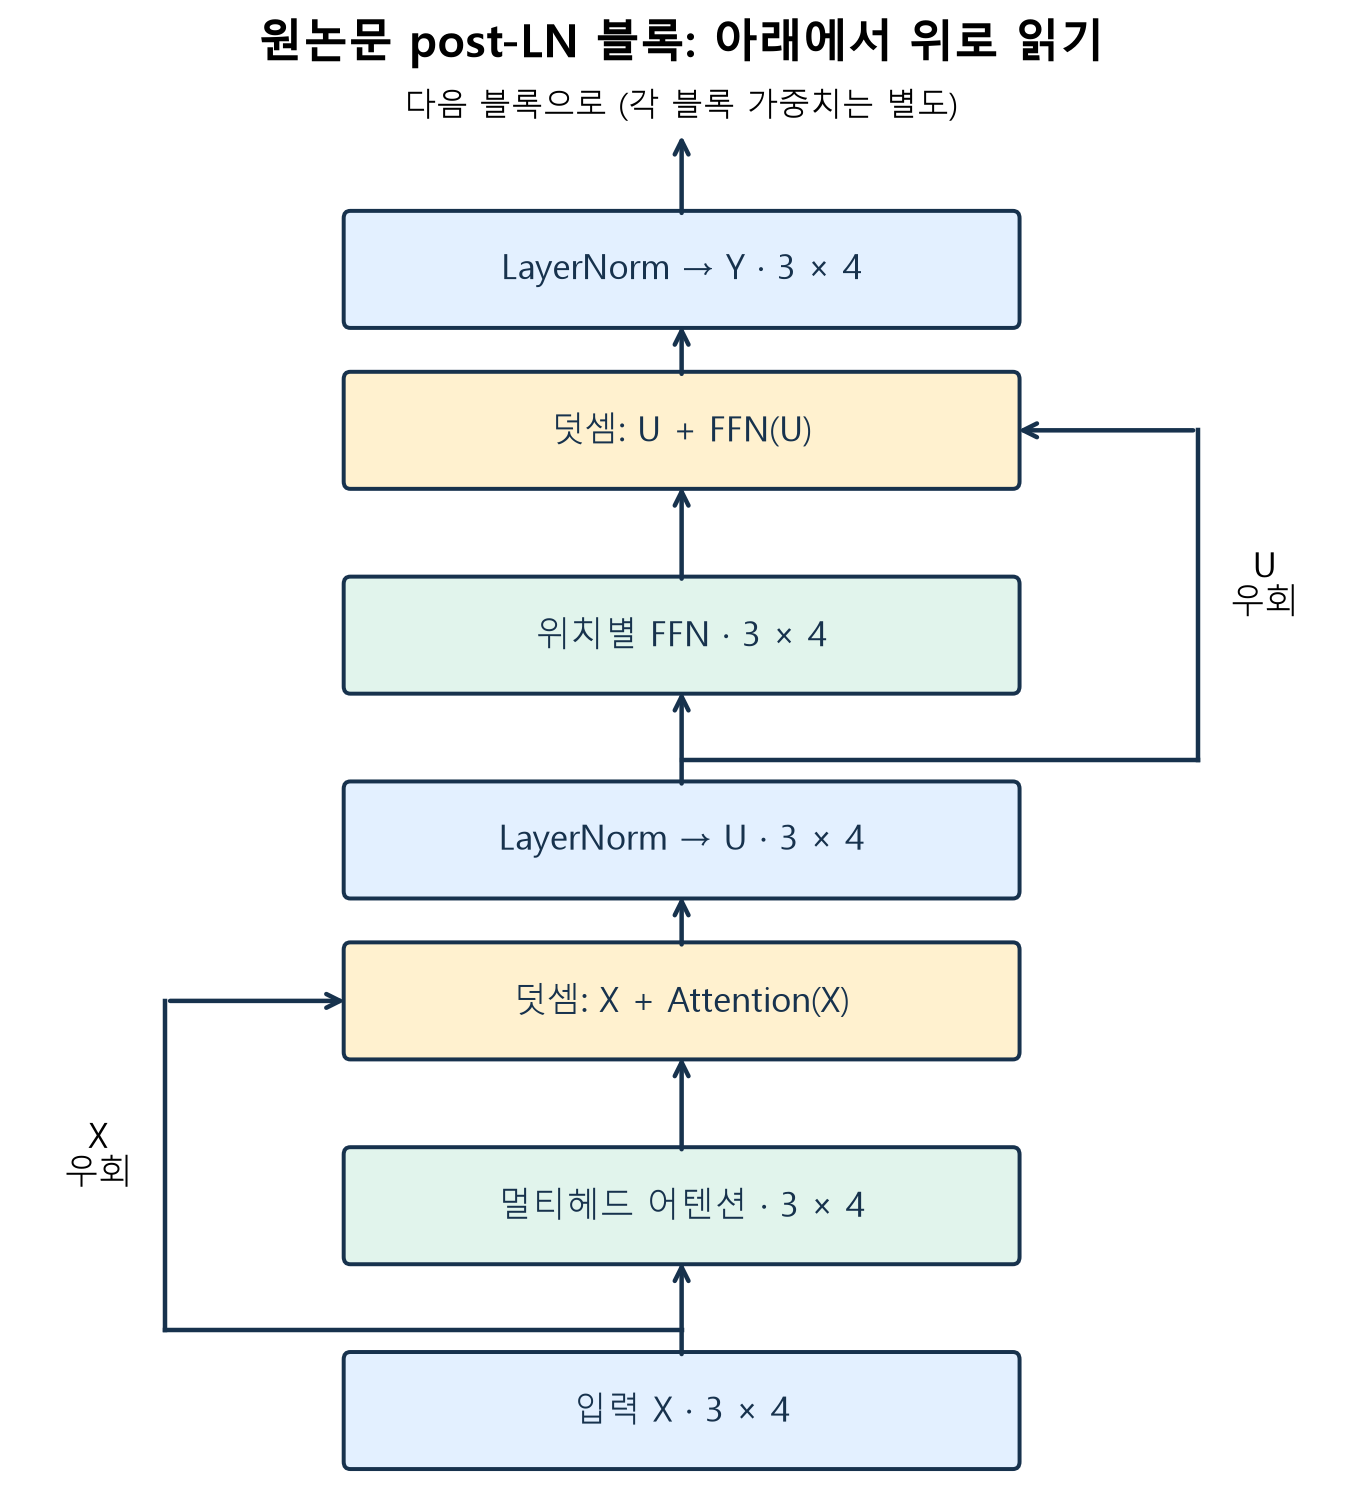
자체 제작. 원논문 post-LN 설명용이며 실제 Qwen 구조와 구별합니다.

처음 쓸 함수: [block_walkthrough 정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w03b/src/luna_genai/walkthrough.py#L16).
`block_walkthrough(causal=True)`는 교육용 중간 배열 dict를 반환합니다. 다운로드·학습 없음.
`X`는 (3,4), `Q/K/V`는 (3,2), `A`는 (3,3), `Z`는 (3,2), `Y`는 (3,4)입니다.
기본 True는 미래 차단, False는 전체 입력 허용입니다. 실제 모델에서 추출한 숫자가 아닙니다.
각 배열의 행=위치, 열=특징입니다. `A`만 행=받는 위치, 열=참고 위치입니다.
예: `b['A'][1]`은 두 번째 위치의 참고 비중 세 개입니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w03b/assets/01-block.png)


In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display
from luna_genai.walkthrough import block_walkthrough
b=block_walkthrough()
for name in ('X','Q','K','V','scores','masked','A','Z'):
    print(name,b[name].shape)
    display(pd.DataFrame(b[name]).round(4))
print('두 번째 위치 가중합:',b['A'][1]@b['V'])


### Exercise A · 행과 마스크
A1. `A[1,2]`는 어느 위치가 어느 위치를 참고하는 값인가요? 왜 0인가요?
A2. `block_walkthrough(False)`로 미래를 허용하면 어느 행이 그대로일까요?
실행 전 예상한 뒤 다음 비교 셀에서 확인하세요. 점수 0과 확률 0의 차이도 말해 보세요.


In [ ]:
unmasked=block_walkthrough(False)
display(pd.DataFrame(unmasked['A']).round(4))
print('미래 차단 때 각 행의 합:',b['A'].sum(axis=1))


## 2. 멀티헤드 → 잔차 → 정규화 → FFN
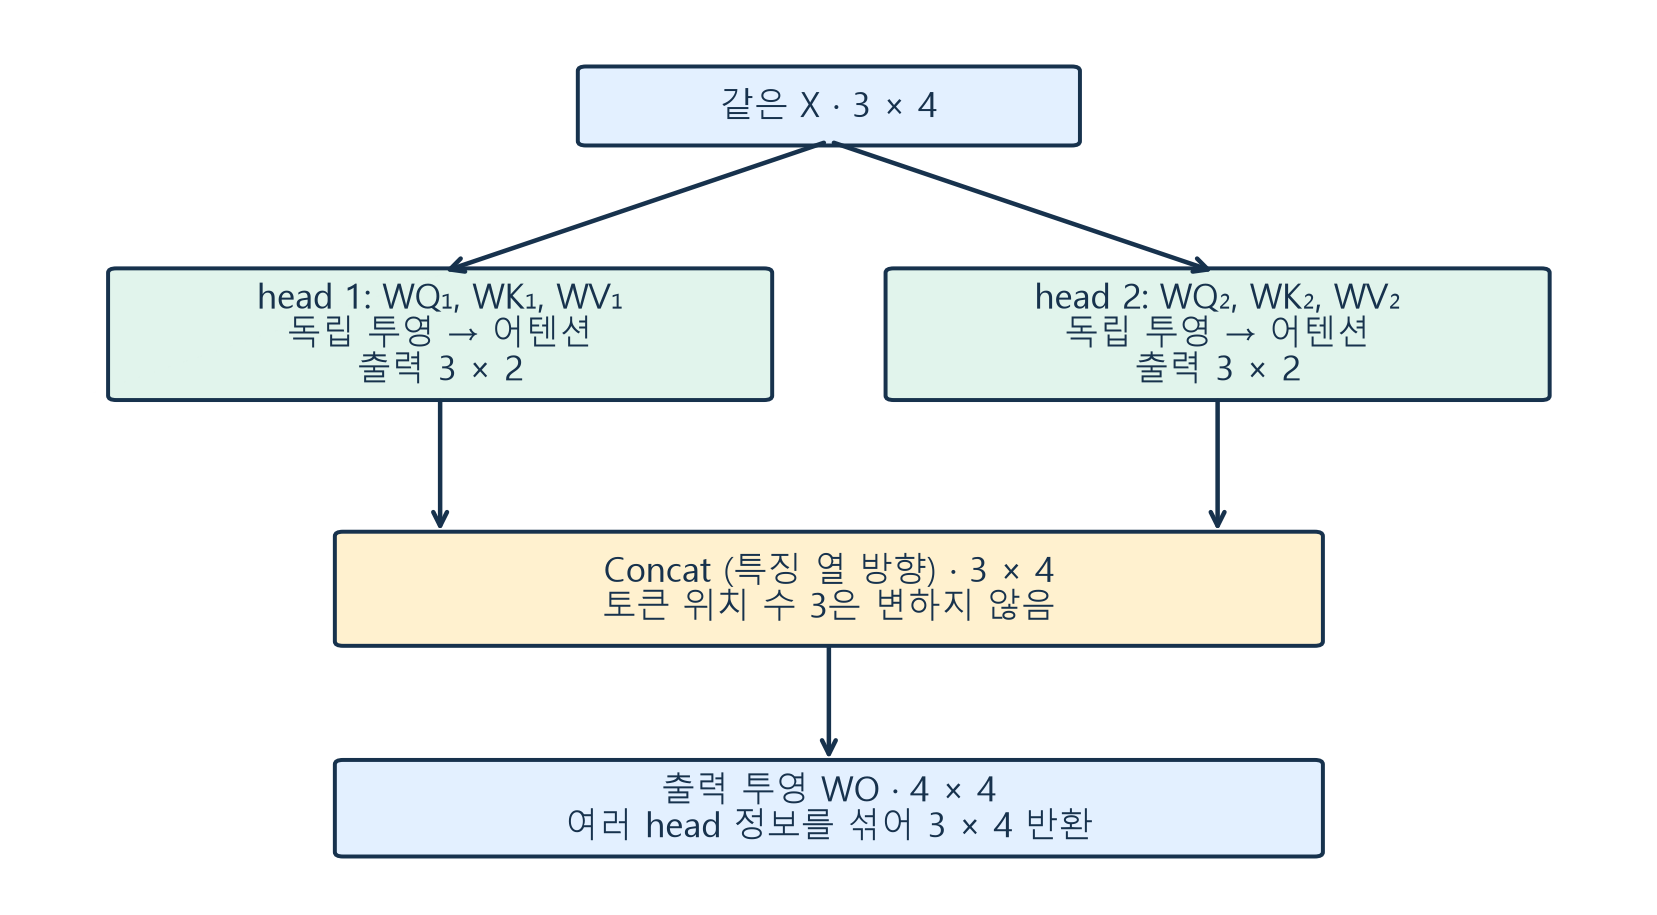
자체 제작. $Z_1,Z_2:(3,2)$를 열 방향으로 합치면 $(3,4)$입니다.
$U=\operatorname{LN}(X+\operatorname{Concat}(Z_1,Z_2)W_O)$,
$Y=\operatorname{LN}(U+\operatorname{FFN}(U))$를 차례로 확인합니다.
`expanded`는 ReLU 직전 (3,6), `activated`는 음수를 0으로 만든 결과,
`ffn`은 다시 (3,4)입니다. LN은 각 행의 특징 축을 정규화합니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w03b/assets/04-heads.png)


In [ ]:
for name in ('head2','concat','projected','residual1','U','expanded','activated','ffn','residual2','Y'):
    print(name,b[name].shape)
    display(pd.DataFrame(b[name]).round(3))


### Exercise B · 잘못된 블록 디버깅
B1. `np.concatenate([b['Z'],b['head2']],axis=0)`을 X에 더하면 왜 틀릴까요?
B2. `expanded`를 바로 U에 더하면 왜 틀릴까요? FFN은 위치 사이 값을 섞나요?


## 3. 실제 Qwen 준비 — 모델은 한 번만 로드
[LanguageModelLab 정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w03b/src/luna_genai/model.py#L13).
`LanguageModelLab(device='cpu',local_files_only=False)`는 고정 revision의 tokenizer/model을 로드합니다.
최초 다운로드·캐시 파일 생성은 여기서 일어납니다. 실패는 오류로 남으며 모의 텍스트로 대체하지 않습니다.
`token_table(text)`는 위치·ID·표기·decode의 표를 반환합니다. 빈 문장/1500자 초과/384토큰 초과는 거절합니다.
실제 Qwen2는 pre-RMSNorm/RoPE/GQA/SwiGLU를 사용합니다. 위 수계산과 동일한 구현은 아닙니다.


In [ ]:
from luna_genai import LanguageModelLab, MODEL_ID, MODEL_REVISION
lab=LanguageModelLab(device='cpu')
print(MODEL_ID,MODEL_REVISION,lab.device)
display(lab.token_table('The sky is'))
cfg=lab.model.config
print('실제 config:',cfg.num_hidden_layers,cfg.hidden_size,cfg.num_attention_heads,cfg.num_key_value_heads,cfg.intermediate_size)


## 4. 한 번 forward → ID 하나 추가
[단계별 함수 정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w03b/src/luna_genai/transformer.py#L59).
- `prompt_ids(lab,prompt)` → [1,n] LongTensor. 토큰화, 입력 검증; 학습 없음.
- `forward_logits(lab,ids)` → 마지막 위치 [V] CPU float Tensor. 실제 model() 한 번.
  `use_cache=False`, inference_mode, generate() 없음. 입력은 변경하지 않습니다.
- `choose_token(logits,strategy='greedy')` → id와 model_probability, selection_probability dict.
  greedy는 가장 큰 로짓 선택. 선택 확률 1은 사실성 신뢰도가 아닙니다.
- `append_token(lab,ids,next_id)` → [1,n+1] 새 tensor. 문자열 재토큰화 없음.
아래 출력의 정확한 문구보다 ID 개수가 하나 늘어나는 흐름을 봅니다.


In [ ]:
from luna_genai.transformer import prompt_ids,forward_logits,choose_token,append_token
ids0=prompt_ids(lab,'The sky is')
logits=forward_logits(lab,ids0)
choice=choose_token(logits)
ids1=append_token(lab,ids0,choice['id'])
print('모양:',tuple(ids0.shape),'→',tuple(logits.shape),'→',tuple(ids1.shape))
print('선택:',choice)
print(lab.tokenizer.decode(ids1[0],skip_special_tokens=True))


## 5. 두 번 연결: 상태에 ID와 기록을 함께 보관
[상태 함수 정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w03b/src/luna_genai/walkthrough.py#L56).
`begin_generation(lab,prompt,limit=8)` → dict: ids, initial_length, rows, limit, reason, prompt.
새 토큰 한도는 정수 1..32. 토큰화만 하며 모델 호출 없음. `rows`는 처음에는 빈 목록입니다.
`step_generation(lab,state)`는 실제 한 토큰을 추가한 **새 dict**를 돌려줍니다. 원본은 그대로.
EOS/한도면 모델 재호출 없이 종료 상태를 반환합니다. 자동 반복 전체를 대신하는 함수는 아닙니다.
`generation_view(lab,state)` → 전체 decode 문장, 6열 DataFrame, 종료 상태 문자열. forward 없음.
기본 한 단계는 greedy이며 모델 확률과 선택 규칙 확률을 구분해 기록합니다.


In [ ]:
from luna_genai.walkthrough import begin_generation,step_generation,generation_view,build_step_app
s0=begin_generation(lab,'The sky is',limit=2)
s1=step_generation(lab,s0)
s2=step_generation(lab,s1)
for state in (s0,s1,s2):
    text,table,status=generation_view(lab,state)
    print(len(state['ids']),text,status)
    display(table)


### Exercise C · 자동 생성 세 빈칸
`s0 → s1 → s2`를 짧은 반복으로 바꿉니다. 빈칸은 상태 갱신, 종료 조건, 화면용 반환입니다.
① step_generation으로 state를 갱신 ② EOS 또는 max_new_tokens면 break
③ generation_view로 결과 반환. model.generate()는 사용하지 않습니다.
TODO를 남겨도 아래 기본 앱은 실행할 수 있습니다. 완성 후 `student_generate(lab,'The sky is',2)`로 확인하세요.


In [ ]:
def student_generate(lab,prompt,limit=4):
    state=begin_generation(lab,prompt,limit)
    for _ in range(state['limit']):
        state = None  # TODO 1: 한 단계 갱신
        if state is None:
            return None  # 미완성 안내용; 가짜 생성 결과를 반환하지 않음
        if False:     # TODO 2: 종료 상태 검사
            break
    return None       # TODO 3: 문장/표/상태 반환
print('Exercise C 함수 정의 완료. 빈칸을 채운 뒤 직접 호출하세요.')


## 6. 기본 관찰 웹앱: 초기화 → 다음 토큰 버튼
[build_step_app 정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w03b/src/luna_genai/walkthrough.py#L132).
`build_step_app(lab)`은 Blocks를 만들 뿐 모델 로드/서버 시작은 하지 않습니다.
어텐션 탭의 숫자는 교육용, 생성 탭은 실제 모델입니다. `gr.State`는 사용자 세션별 dict를 보관합니다.
문장/한도 변경 뒤 초기화를 요구합니다. 두 callback은 입력과 출력 순서가 다릅니다.
reset(prompt,limit) → state,text,table,status / advance(prompt,limit,state) → 같은 네 출력.
`.launch()`는 서버를 시작하는 별도 동작입니다. 기본은 share=False입니다.


In [ ]:
app=build_step_app(lab)
RUN_LOCAL_APP=False  # 로컬에서 앱을 열려면 True로 바꾸고 실행
if RUN_LOCAL_APP:
    app.launch(share=False,prevent_thread_lock=True)
print('앱 준비 완료. 어텐션 계산과 실제 토큰 누적 탭이 있습니다.')


Colab에서는 외부 연결을 위해 임시 공유를 선택할 수 있습니다. 아래 셀을 직접 수정한 경우만
공개 링크를 만듭니다. 개인정보를 넣지 마세요. 링크는 실행 중인 런타임에 의존합니다.
아래 기본 False 상태는 공개 서버를 만들지 않으며 자동 검증에서도 유지합니다.


In [ ]:
ENABLE_PUBLIC_SHARE=False
if ENABLE_PUBLIC_SHARE:
    app.launch(share=True,prevent_thread_lock=True)


### Exercise D · 버튼을 직접 연결
[Gradio 공식 Blocks 안내](https://www.gradio.app/guides/blocks-and-event-listeners).
`button.click(fn,inputs=[...],outputs=[...])`는 버튼 클릭 시 입력값을 함수 인자 순서로 전달하고
반환값을 출력 컴포넌트 순서로 표시합니다. `gr.Textbox`는 문자열, `gr.Slider`는 숫자를 줍니다.
D1. C가 완성되면 아래 callback과 click 한 줄을 연결하세요. 입력은 prompt,limit 순서,
반환은 text,table,status 순서입니다. 미완성일 때는 gr.Error로 안내하고 가짜 결과를 내지 않습니다.
D2. 버튼을 연속 클릭할 때 다른 사용자와 상태를 섞지 않으려면 어디에 저장해야 할까요?


In [ ]:
import gradio as gr
def student_callback(prompt,limit):
    result=student_generate(lab,prompt,int(limit))
    if result is None:
        raise gr.Error('Exercise C를 먼저 완성하세요.')
    return result
with gr.Blocks(title='내 자동 생성 앱') as student_app:
    prompt_box=gr.Textbox(value='The sky is',label='입력 문장')
    limit_box=gr.Slider(1,32,value=4,step=1,label='새 토큰 한도')
    run_button=gr.Button('자동 생성')
    text_box=gr.Textbox(label='문장')
    table_box=gr.Dataframe(label='기록')
    status_box=gr.Textbox(label='상태')
    # TODO: run_button.click(fn=..., inputs=[...], outputs=[...])
print('UI 골격 준비. click 연결 후 student_app.launch(share=False)로 실행합니다.')


### Exercise E · 모델 선택과 선택 확장
E1. BERT/Qwen/T5 중 이어쓰기를 직접 실습할 출발 모델은 무엇이며, T5는 왜 decoder-only가 아닌가요?
E2. 아래 온도/seed 변경은 모델 가중치를 학습시키나요? greedy와 sampling의 확률을 구별하세요.
선택 확장: `choose_token(strategy='sample',temperature=.8,top_k=10,rng=...)`는
상위 후보를 온도로 조정한 분포에서 뽑습니다. rng는 NumPy Generator이며 한 반복에서 재사용합니다.
동일 환경/로짓/seed의 재현성이지 모든 하드웨어에서 동일 문장을 보장한다는 뜻은 아닙니다.


In [ ]:
sample=choose_token(logits,strategy='sample',temperature=.8,top_k=10,rng=np.random.default_rng(17))
print('greedy:',choice,'sample:',sample)


In [ ]:
assert np.allclose(b['A'].sum(1),1) and np.all(b['A'][np.triu_indices(3,1)]==0)
assert np.allclose(b['Z'][1],[.33023845,1.3395231],atol=1e-6)
assert b['X'].shape==b['Y'].shape==(3,4)
assert ids1.shape[1]==ids0.shape[1]+1 and choice['id']==int(logits.argmax())
assert len(s0['rows'])==0 and s1['ids']==ids1[0].tolist()
assert len(s2['rows'])==2 and s2['reason']=='max_new_tokens'
assert step_generation(lab,s2)==s2
other=begin_generation(lab,'A small robot',2)
assert other['rows']==[] and s0['rows']==[]
reset=app.lesson_reset('The sky is',2)
advanced=app.lesson_advance('The sky is',2,reset[0])
assert advanced[0]['ids']==s1['ids'] and len(reset[0]['rows'])==0
assert len(advanced[2])==1 and advanced[1].strip()
try:
    app.lesson_advance('Different prompt',2,advanced[0])
except gr.Error:
    pass
else:
    raise AssertionError('입력 변경 후 초기화 요구 누락')
print('학생 검증 통과: 교육용 수치 + 실제 forward + 상태 누적 + callback. 실제 브라우저/Colab 검증과 구별합니다.')


## 마무리
ID를 유지한 채 한 토큰씩 늘리면 자동 생성 루프가 됩니다. 모델의 가중치는 바꾸지 않았습니다.
같은 구조도에서 어텐션은 위치 간 정보 혼합, FFN은 위치별 특징 변환, 잔차는 원래 경로 보존입니다.
기본 모델은 사실 오류·편향·반복을 만들 수 있습니다. 실험 기록과 별도 퀴즈로 복습하세요.
